# Sales Prediction Using Python

## CodSoft Data Science Internship – Task 4

This project uses advertising data to build a machine learning model
that predicts sales based on advertising expenditure.

The project includes data exploration, visualization, preprocessing,
model training, and evaluation.

## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving advertising.csv to advertising.csv


## 2. Loading the Dataset

In [3]:
filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File used:", filename)
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
File used: advertising.csv
Dataset shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Column names:
['TV', 'Radio', 'Newspaper', 'Sales']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


## 3. Exploratory Data Analysis

The dataset contains advertising expenditure on TV, Radio, and Newspaper,
along with the corresponding sales. Exploratory analysis is performed
to understand the relationships between advertising expenditure and sales.

In [7]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


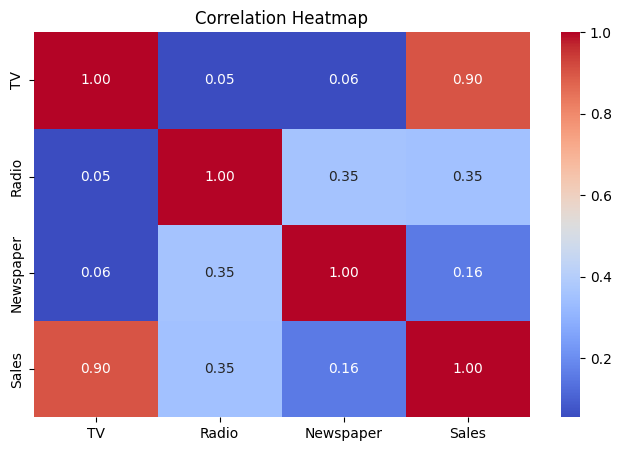

In [8]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

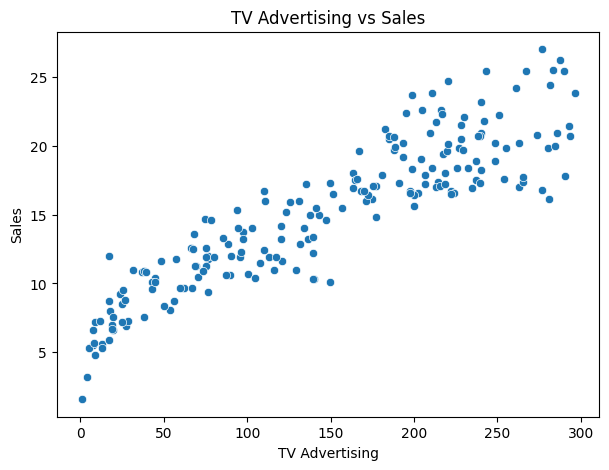

In [9]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="TV", y="Sales")
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.show()

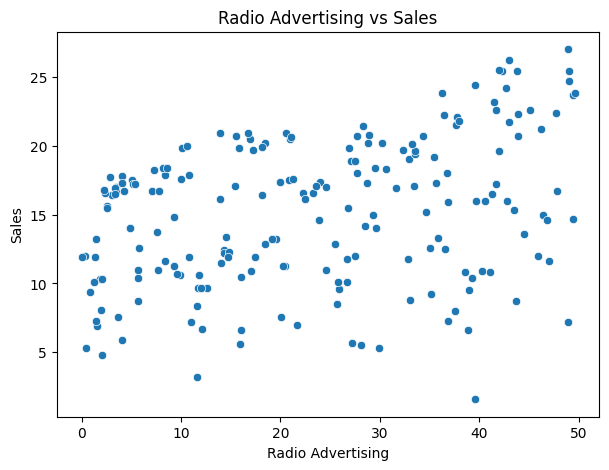

In [10]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Radio", y="Sales")
plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.show()

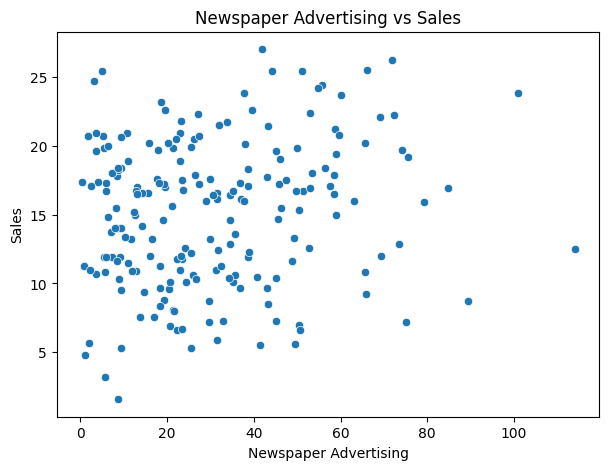

In [11]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Newspaper", y="Sales")
plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")
plt.show()

## 4. Data Preprocessing

The advertising expenditure columns are used as input features, while
Sales is used as the target variable.

In [12]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (160, 3)
Testing data shape: (40, 3)


## 5. Model Training

Linear Regression is used to model the relationship between advertising
expenditure and sales. The model learns from the training data and is
then used to predict sales for unseen data.

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [15]:
y_pred = model.predict(X_test)

print("First 10 Actual Sales:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Sales:")
print(y_pred[:10])

First 10 Actual Sales:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 16.5 16.1]

First 10 Predicted Sales:
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475]


## 6. Model Evaluation

The model is evaluated using Mean Absolute Error, Mean Squared Error,
Root Mean Squared Error, and R² score.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation:
Mean Absolute Error (MAE): 1.2748262109549338
Mean Squared Error (MSE): 2.9077569102710896
Root Mean Squared Error (RMSE): 1.7052146229349223
R² Score: 0.9059011844150826


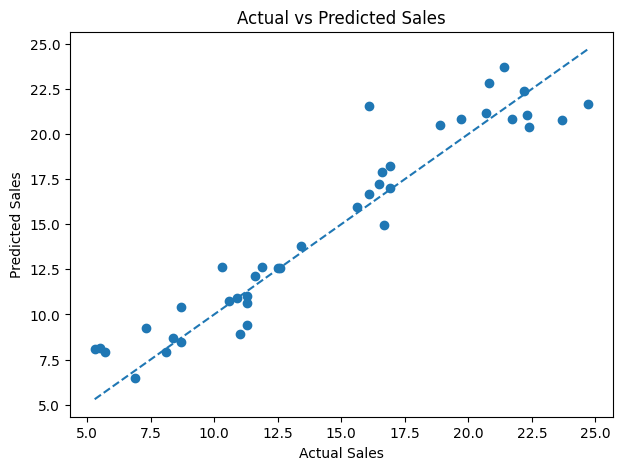

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

## 7. Making a Prediction on New Advertising Data

The trained model is used to predict sales for a new advertising
budget given for TV, Radio, and Newspaper.

In [18]:
new_advertising = pd.DataFrame({
    "TV": [100],
    "Radio": [25],
    "Newspaper": [20]
})

predicted_sales = model.predict(new_advertising)

print("New Advertising Data:")
print(new_advertising)

print("\nPredicted Sales:", predicted_sales[0])

New Advertising Data:
    TV  Radio  Newspaper
0  100     25         20

Predicted Sales: 12.77542048220068


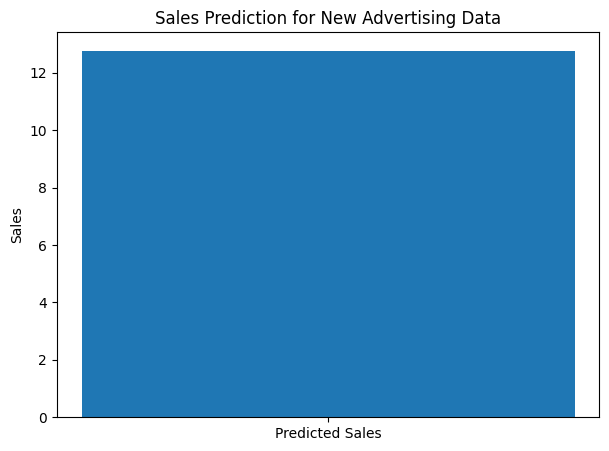

In [19]:
plt.figure(figsize=(7, 5))
plt.bar(["Predicted Sales"], [predicted_sales[0]])
plt.ylabel("Sales")
plt.title("Sales Prediction for New Advertising Data")
plt.show()

## 8. Model Coefficients

The coefficients show how each advertising channel contributes to the
predicted sales while keeping the other variables constant.

In [20]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)
print("\nIntercept:", model.intercept_)

     Feature  Coefficient
0         TV     0.054509
1      Radio     0.100945
2  Newspaper     0.004337

Intercept: 4.714126402214127


## 9. Conclusion

A Linear Regression model was successfully developed to predict sales
using TV, Radio, and Newspaper advertising expenditure.

The model was trained on the advertising dataset and evaluated using
MAE, MSE, RMSE, and R² score. The model can also predict sales for new
advertising expenditure values.

This project demonstrates how machine learning can be used to analyze
advertising data and support sales prediction.

## 10. Project Workflow

1. Load the advertising dataset.
2. Explore the dataset and check for missing values.
3. Perform statistical analysis and visualization.
4. Analyze correlations between advertising channels and sales.
5. Split the data into training and testing sets.
6. Train a Linear Regression model.
7. Predict sales on the test data.
8. Evaluate the model using regression metrics.
9. Predict sales for new advertising data.
10. Summarize the results.